In [ ]:
#Kullanılan kütüphaneler ve modüller 
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from scipy import stats
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc



In [ ]:
#Dataset yüklemek için
df = pd.read_excel("Dry_Bean_Dataset.xlsx")

#Veri setinin ilk birkaç satırını görüntülemek için (emin olmak için önemli)
print("Initial data snapshot:")
print(df.head())

#Veride halihazırda eksik veri var mı görmek için
print(df.isnull().sum())

#İki rastgele sütuna 5% missing value eklemek için 
for col in ['EquivDiameter', 'roundness']:
    df.loc[df.sample(frac=0.05, random_state=42).index, col] = np.nan
#Bu sayede real-life data corruption simüle edilmiş oluyor

#Başka bir sütuna 35% missing value eklemek için
df.loc[df.sample(frac=0.35, random_state=7).index, 'Compactness'] = np.nan
#Burada da daha büyük bir veri eksikliği çalışılıyor, veriler yanlışlıkla silinebilir veya belli faktörler yüzünden elde edilemeyebilir

#Veri setini cvs dosyası olarak dışa aktarmak için
df.to_csv("Dry_Bean_Missing_Example.csv", index=False)

#Veri setinin ne kadar broken olduğunu görmek için
print("\nMissing values per column:")
print(df.isnull().sum())




Initial data snapshot:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0

In [49]:
#5% missing value olan sütunları ortalama ile doldurmak gerekiyor
df['EquivDiameter'] = df['EquivDiameter'].fillna(df['EquivDiameter'].mean())
df['roundness'] = df['roundness'].fillna(df['roundness'].mean())

#35% missing sütun bu dakikadan itibaren bizim için ölmüştür: 
df = df.drop(columns=['Compactness']) 
#Çalışma için kritik değilse ve çok fazla eksik veri barındırıyorsa, onu tutmak çok riskli olacaktır

#Veri setinin son halini kontrol etmek için
print("\nRemaining missing values:")
print(df.isnull().sum())



Remaining missing values:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [50]:
#Outlier'ları silmek için Z-score
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
df = df[(z_scores <3).all(axis=1)]
#Z-score 3'ten büyük olanları siliyoruz (güven aralığı %99.7)

In [51]:
#StandardScaler ile verileri aynı ölçeğe getirmek için
scaler = StandardScaler() #bir veri 1-10000 aralığındayken diğeri 0-1 arasındaysa modelin öğrenmesi zorlaşır
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

#LabelEncoder ile Class sütunlarını numerik hale dönüştürmek için
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])

#Veri setinin son halini kontrol etmek için
print("\nFinal preprocessed data:")
print(df.head())

#Veri setindeki 0 değeri -> tam olarak ortalamaya eşit 
#               (-) değer -> ortalamanın altında
#               (+) değer -> ortalamanın üstünde
#Classlar fasulye genotiplerine göre encode edildi



Final preprocessed data:
       Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0 -1.179696  -1.340630        -1.507916        -0.721257     -1.582858   
2 -1.120449  -1.253114        -1.437459        -0.652072     -1.530552   
3 -1.082676  -1.115221        -1.471840        -0.428995     -1.764796   
5 -1.066376  -1.184611        -1.441484        -0.463084     -1.691989   
6 -1.054466  -0.962286        -1.464380        -0.377420     -1.793493   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0     -2.290172   -1.177045      -1.346331  0.282084  0.353266   1.480018   
2     -2.142456   -1.119431      -1.264990  0.588445  0.550526   1.294350   
3     -2.875724   -1.058331      -1.213840  0.687063 -3.059968   0.493257   
5     -2.626564   -1.065658      -1.191933  0.536097  0.536781   1.221422   
6     -2.980240   -1.043794      -1.175988  0.249247 -0.986914  -0.434504   

   ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  

Seçilen PCA bileşenleri: [0 1 2]


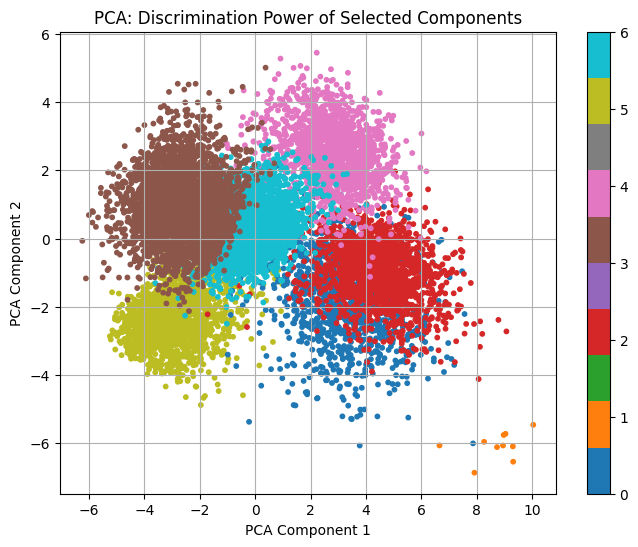

In [52]:
#preprocessed veriyi kaydetmek için
X = df.drop('Class', axis=1)
y = df['Class']
X_ham = X.copy()
y_ham = y.copy()

#PCA uygulamak için
pca = PCA()
X_pca_full = pca.fit_transform(X)

#Average variance explained by each component hesaplamak için 
explained_variance = pca.explained_variance_ratio_
average_variance = np.mean(explained_variance)

# PCA bileşenlerini seçmek için
selected_components = np.where(explained_variance > average_variance)[0]
print(f"Seçilen PCA bileşenleri: {selected_components}")

#Seçilen bileşenleri azaltmak için
pca_selected = PCA(n_components=len(selected_components))
X_pca = pca_selected.fit_transform(X)

#PCA verilerini kaydetmek için
X_pca_data = X_pca
y_pca_data = y.copy()

#PCA verilerini 2D olarak görselleştirmek için
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA: Discrimination Power of Selected Components')
plt.colorbar()
plt.grid(True)
plt.show()


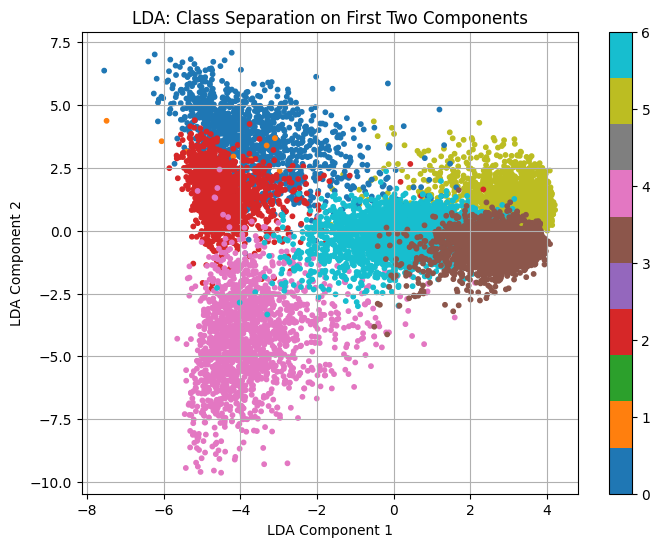

In [54]:
#3 bileşenli LDA uygulamak için
lda = LDA(n_components=3)
X_lda = lda.fit_transform(X,y)

#LDA verilerini kaydetmek için
X_lda_data = X_lda
y_lda_data = y.copy()

#İlk iki LDA bileşenini görselleştirmek için
plt.figure(figsize=(8,6))
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='tab10', s=10)
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.title('LDA: Class Separation on First Two Components')
plt.colorbar()
plt.grid(True)
plt.show()


In [ ]:
#Ham veri için dataset
X_use = X_ham
y_use = y_ham

#Outer CV (5-fold), random_state her loopta değişiyor
outer_cv = StratifiedKFold(n_splits=5, shuffle=True)
#Inner CV (5-fold), random_state sabit
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#Hyperparemeter belirlemek için
param_grid = {
    'C' : [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
outer_scores = []

#Outer loop için
fold_idx = 1
for train_idx, test_idx in outer_cv.split(X_use, y_use):
    print(f"Starting Outer Fold {fold_idx}...")
    X_train, X_test = X_use.iloc[train_idx], X_use.iloc[test_idx]
    y_train, y_test = y_use.iloc[train_idx], y_use.iloc[test_idx]

    #Inner loop için
    model = LogisticRegression(max_iter=1000)
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=inner_cv, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    #En iyi modeli outer test seti üzerinde değerlendirmek için
    test_score = best_model.score(X_test, y_test)
    outer_scores.append(test_score)

    print(f"Fold {fold_idx} Accuracy: {test_score:.4f}")
    fold_idx += 1

#Sonuçları yazdırmak için
print("\nOuter Nested CV Accuracy:")
print(f"Mean Accuracy: {np.mean(outer_scores):.4f}")
print(f"Standard Deviation: {np.std(outer_scores):.4f}")




Starting Outer Fold 1...
Fold 1 Accuracy: 0.9235
Starting Outer Fold 2...
Fold 2 Accuracy: 0.9119
Starting Outer Fold 3...
Fold 3 Accuracy: 0.9303
Starting Outer Fold 4...
Fold 4 Accuracy: 0.9255
Starting Outer Fold 5...
Fold 5 Accuracy: 0.9251

Outer Nested CV Accuracy:
Mean Accuracy: 0.9233
Standard Deviation: 0.0061


In [56]:
#PCA ve LDA verileri Numpy dizisinde olduğu için .iloc[] olarak okunmayacak
#Pandas DataFrame'e dönüştürmek için
X_pca_data = pd.DataFrame(X_pca_data)
y_pca_data = pd.Series(y_pca_data)


#PCA verileri için aynı işlemler
X_use = X_pca_data
y_use = y_pca_data

#Outer CV ve Inner CV için
outer_cv = StratifiedKFold(n_splits=5, shuffle=True)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#Hyperparemeter belirlemek için
param_grid = {
    'C' : [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
outer_scores = []

#Outer loop için
fold_idx = 1
for train_idx, test_idx in outer_cv.split(X_use, y_use):
    print(f"Starting Outer Fold {fold_idx}...")
    X_train, X_test = X_use.iloc[train_idx], X_use.iloc[test_idx]
    y_train, y_test = y_use.iloc[train_idx], y_use.iloc[test_idx]

    #Inner loop için
    model = LogisticRegression(max_iter=1000)
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=inner_cv, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    #En iyi modeli outer test seti üzerinde değerlendirmek için
    test_score = best_model.score(X_test, y_test)
    outer_scores.append(test_score)

    print(f"Fold {fold_idx} Accuracy: {test_score:.4f}")
    fold_idx += 1

#Sonuçları yazdırmak için
print("\nOuter Nested CV Accuracy:")
print(f"Mean Accuracy: {np.mean(outer_scores):.4f}")
print(f"Standard Deviation: {np.std(outer_scores):.4f}")

Starting Outer Fold 1...
Fold 1 Accuracy: 0.8694
Starting Outer Fold 2...
Fold 2 Accuracy: 0.8734
Starting Outer Fold 3...
Fold 3 Accuracy: 0.8943
Starting Outer Fold 4...
Fold 4 Accuracy: 0.8846
Starting Outer Fold 5...
Fold 5 Accuracy: 0.8710

Outer Nested CV Accuracy:
Mean Accuracy: 0.8786
Standard Deviation: 0.0095


In [57]:
X_lda_data = pd.DataFrame(X_lda_data)
y_lda_data = pd.Series(y_lda_data)

#LDA verileri için aynı işlemler
X_use = X_lda_data
y_use = y_lda_data

#Outer CV ve Inner CV için
outer_cv = StratifiedKFold(n_splits=5, shuffle=True)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#Hyperparemeter belirlemek için
param_grid = {
    'C' : [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
outer_scores = []

#Outer loop için
fold_idx = 1
for train_idx, test_idx in outer_cv.split(X_use, y_use):
    print(f"Starting Outer Fold {fold_idx}...")
    X_train, X_test = X_use.iloc[train_idx], X_use.iloc[test_idx]
    y_train, y_test = y_use.iloc[train_idx], y_use.iloc[test_idx]

    #Inner loop için
    model = LogisticRegression(max_iter=1000)
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=inner_cv, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    #En iyi modeli outer test seti üzerinde değerlendirmek için
    test_score = best_model.score(X_test, y_test)
    outer_scores.append(test_score)

    print(f"Fold {fold_idx} Accuracy: {test_score:.4f}")
    fold_idx += 1

#Sonuçları yazdırmak için
print("\nOuter Nested CV Accuracy:")
print(f"Mean Accuracy: {np.mean(outer_scores):.4f}")
print(f"Standard Deviation: {np.std(outer_scores):.4f}")

Starting Outer Fold 1...
Fold 1 Accuracy: 0.9075
Starting Outer Fold 2...
Fold 2 Accuracy: 0.9111
Starting Outer Fold 3...
Fold 3 Accuracy: 0.9071
Starting Outer Fold 4...
Fold 4 Accuracy: 0.9054
Starting Outer Fold 5...
Fold 5 Accuracy: 0.9131

Outer Nested CV Accuracy:
Mean Accuracy: 0.9088
Standard Deviation: 0.0028


In [65]:
# Combine results from all three datasets
results_ham['Representation'] = 'Ham Veri'
results_pca['Representation'] = 'PCA Verisi'
results_lda['Representation'] = 'LDA Verisi'

# Combine and clean
comparison_df = pd.concat([results_ham, results_pca, results_lda])
comparison_df.reset_index(inplace=True)
comparison_df.rename(columns={'index': 'Model'}, inplace=True)

# Optional: only show essential columns
table_df = comparison_df[['Representation', 'Model', 'Mean Accuracy', 'Standard Deviation']]

from tabulate import tabulate

# Print it like a pretty Excel table in terminal
print(tabulate(table_df, headers='keys', tablefmt='grid', showindex=False))

+------------------+-------------+-----------------+----------------------+
| Representation   | Model       |   Mean Accuracy |   Standard Deviation |
+==================+=============+=================+======================+
| Ham Veri         | Naive Bayes |        0.894095 |           0.0100413  |
+------------------+-------------+-----------------+----------------------+
| PCA Verisi       | Naive Bayes |        0.868541 |           0.00746361 |
+------------------+-------------+-----------------+----------------------+
| LDA Verisi       | Naive Bayes |        0.894337 |           0.00373989 |
+------------------+-------------+-----------------+----------------------+


In [ ]:
#Model ve grid tanımlamak için
model_and_grids ={
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            'C' : [0.01, 0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['lbfgs']
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(),
        "params": {
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(),
        "params": {
            'n_estimators': [50, 100],
            'max_depth': [5, 10, None]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(eval_metric='mlogloss'),
        "params": {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1]
        }
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {}
    }
}

#Tekrar kullanılabilir nested CV fonksiyonu tanımlamak için

def run_nested_cv_all_models(X, y, models_and_grids):
    results = {}
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True)
    inner_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for name, config in models_and_grids.items():
        print(f"\nRunning model: {name}")
        outer_scores = []
        
        fold_idx = 1
        for train_idx, test_idx in outer_cv.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            if config["params"]:
                grid = GridSearchCV(estimator=config["model"], param_grid=config["params"], cv=inner_cv, scoring='accuracy')
                grid.fit(X_train, y_train)
                best_model = grid.best_estimator_
            else: #Naive Bayes için çünkü ona parametre belirlenmedi
                best_model = config["model"]
                best_model.fit(X_train, y_train)

            score = best_model.score(X_test, y_test)
            outer_scores.append(score)
            print(f"Fold {fold_idx} Accuracy: {score:.4f}")
            fold_idx += 1

        mean_acc = np.mean(outer_scores)
        std_acc = np.std(outer_scores)
        results[name] = {"Mean Accuracy": mean_acc, "Standard Deviation": std_acc}
    
    return pd.DataFrame(results).T

X_ham = pd.DataFrame(X_ham)
y_ham = pd.Series(y_ham)
X_pca_data = pd.DataFrame(X_pca_data)
y_pca_data = pd.Series(y_pca_data)
X_lda_data = pd.DataFrame(X_lda_data)
y_lda_data = pd.Series(y_lda_data)

results_ham = run_nested_cv_all_models(X_ham, y_ham, model_and_grids)
results_pca = run_nested_cv_all_models(X_pca_data, y_pca_data, model_and_grids)
results_lda = run_nested_cv_all_models(X_lda_data, y_lda_data, model_and_grids)

#Sonuçları tablolar halinde yazdırmak için
print("\nResults for Ham Data:")
print(results_ham)

print("\nResults for PCA Data:")
print(results_pca)

print("\nResults for LDA Data:")
print(results_lda)


Running model: Logistic Regression
Fold 1 Accuracy: 0.9259
Fold 2 Accuracy: 0.9183
Fold 3 Accuracy: 0.9239
Fold 4 Accuracy: 0.9199
Fold 5 Accuracy: 0.9267

Running model: Decision Tree
Fold 1 Accuracy: 0.9035
Fold 2 Accuracy: 0.8959
Fold 3 Accuracy: 0.8987
Fold 4 Accuracy: 0.9111
Fold 5 Accuracy: 0.9038

Running model: Random Forest
Fold 1 Accuracy: 0.9211
Fold 2 Accuracy: 0.9231
Fold 3 Accuracy: 0.9215
Fold 4 Accuracy: 0.9147
Fold 5 Accuracy: 0.9135

Running model: XGBoost
Fold 1 Accuracy: 0.9211
Fold 2 Accuracy: 0.9235
Fold 3 Accuracy: 0.9335
Fold 4 Accuracy: 0.9163
Fold 5 Accuracy: 0.9235

Running model: Naive Bayes
Fold 1 Accuracy: 0.8991
Fold 2 Accuracy: 0.8999
Fold 3 Accuracy: 0.8911
Fold 4 Accuracy: 0.8874
Fold 5 Accuracy: 0.8918

Running model: Logistic Regression
Fold 1 Accuracy: 0.8807
Fold 2 Accuracy: 0.8795
Fold 3 Accuracy: 0.8722
Fold 4 Accuracy: 0.8834
Fold 5 Accuracy: 0.8758

Running model: Decision Tree
Fold 1 Accuracy: 0.8602
Fold 2 Accuracy: 0.8546
Fold 3 Accuracy: 0

In [59]:

def run_nested_cv_all_metrics(X, y, models_and_grids):
    results = {}
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for name, config in models_and_grids.items():
        print(f"\nRunning model: {name}")

        acc_list, prec_list, rec_list, f1_list = [], [], [], []

        for train_idx, test_idx in outer_cv.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            if config["params"]:
                grid = GridSearchCV(estimator=config["model"], param_grid=config["params"], cv=inner_cv, scoring='accuracy')
                grid.fit(X_train, y_train)
                best_model = grid.best_estimator_
            else:
                best_model = config["model"]
                best_model.fit(X_train, y_train)

            y_pred = best_model.predict(X_test)

            acc_list.append(accuracy_score(y_test, y_pred))
            prec_list.append(precision_score(y_test, y_pred, average='macro', zero_division=0))
            rec_list.append(recall_score(y_test, y_pred, average='macro'))
            f1_list.append(f1_score(y_test, y_pred, average='macro'))

        results[name] = {
            'Accuracy (mean)': np.mean(acc_list),
            'Accuracy (std)': np.std(acc_list),
            'Precision (mean)': np.mean(prec_list),
            'Precision (std)': np.std(prec_list),
            'Recall (mean)': np.mean(rec_list),
            'Recall (std)': np.std(rec_list),
            'F1 (mean)': np.mean(f1_list),
            'F1 (std)': np.std(f1_list),
        }

    return pd.DataFrame(results).T


# Tüm verisetlerinin doğru formatta olduğundan emin olmak için kontrol tekrarı
X_ham = pd.DataFrame(X_ham)
y_ham = pd.Series(y_ham)

X_pca_data = pd.DataFrame(X_pca_data)
y_pca_data = pd.Series(y_pca_data)

X_lda_data = pd.DataFrame(X_lda_data)
y_lda_data = pd.Series(y_lda_data)

# Ham veri, PCA verisi ve LDA verisi için tüm metrikleri çalıştırmak için
print("\nRunning on raw data:")
results_ham_metrics = run_nested_cv_all_metrics(X_ham, y_ham, model_and_grids)

print("\nRunning on PCA data:")
results_pca_metrics = run_nested_cv_all_metrics(X_pca_data, y_pca_data, model_and_grids)

print("\nRunning on LDA data:")
results_lda_metrics = run_nested_cv_all_metrics(X_lda_data, y_lda_data, model_and_grids)



Running on raw data:

Running model: Logistic Regression

Running model: Decision Tree

Running model: Random Forest

Running model: XGBoost

Running model: Naive Bayes

Running on PCA data:

Running model: Logistic Regression

Running model: Decision Tree

Running model: Random Forest

Running model: XGBoost

Running model: Naive Bayes

Running on LDA data:

Running model: Logistic Regression

Running model: Decision Tree

Running model: Random Forest

Running model: XGBoost

Running model: Naive Bayes


In [60]:
results_ham_metrics['Data Type'] = 'Ham Veri'
results_pca_metrics['Data Type'] = 'PCA Veri'
results_lda_metrics['Data Type'] = 'LDA Veri'

all_metrics = pd.concat([results_ham_metrics, results_pca_metrics, results_lda_metrics])
all_metrics.reset_index(inplace=True)
all_metrics.rename(columns={'index': 'Model'}, inplace=True)

#Tablo oluşturmak için
print("\nFinal Performance Metrics Summary:")
print(all_metrics)


Final Performance Metrics Summary:
                  Model  Accuracy (mean)  Accuracy (std)  Precision (mean)  \
0   Logistic Regression         0.922455        0.002712          0.939790   
1         Decision Tree         0.904270        0.003596          0.880122   
2         Random Forest         0.920452        0.005750          0.937631   
3               XGBoost         0.924138        0.006982          0.941679   
4           Naive Bayes         0.894336        0.005560          0.910254   
5   Logistic Regression         0.878876        0.002880          0.878278   
6         Decision Tree         0.858368        0.004190          0.826828   
7         Random Forest         0.879115        0.006201          0.880094   
8               XGBoost         0.880477        0.004079          0.881105   
9           Naive Bayes         0.869742        0.006538          0.873999   
10  Logistic Regression         0.908835        0.005960          0.926340   
11        Decision Tree     

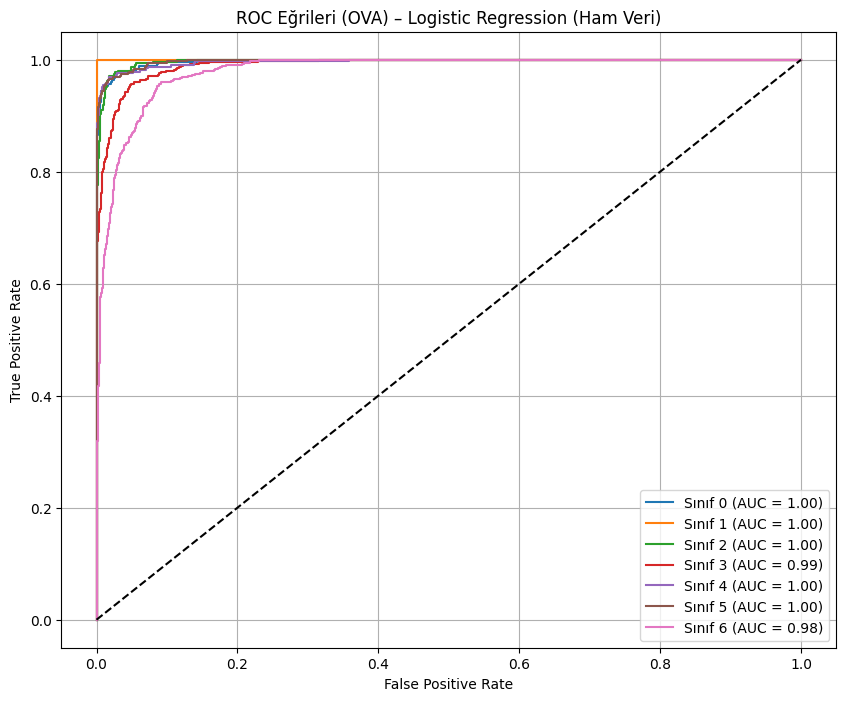

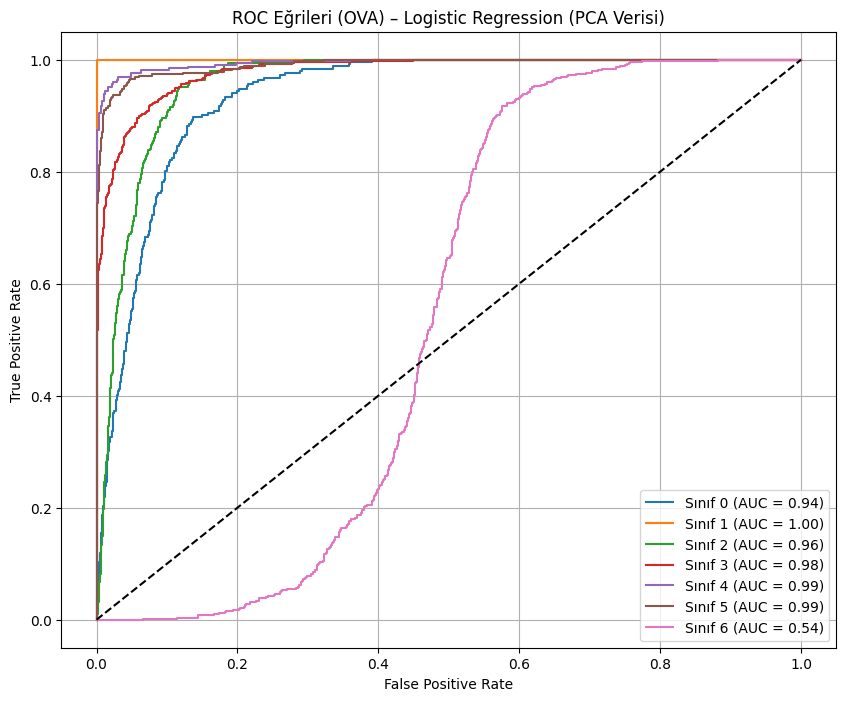

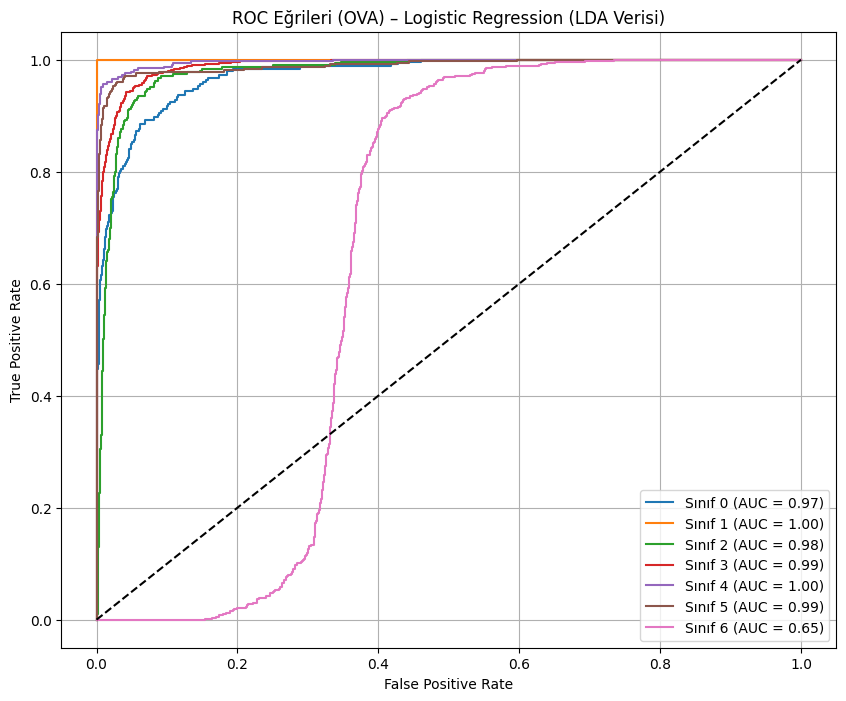


ROC eğrisi çiziliyor: Logistic Regression (Ham Veri)


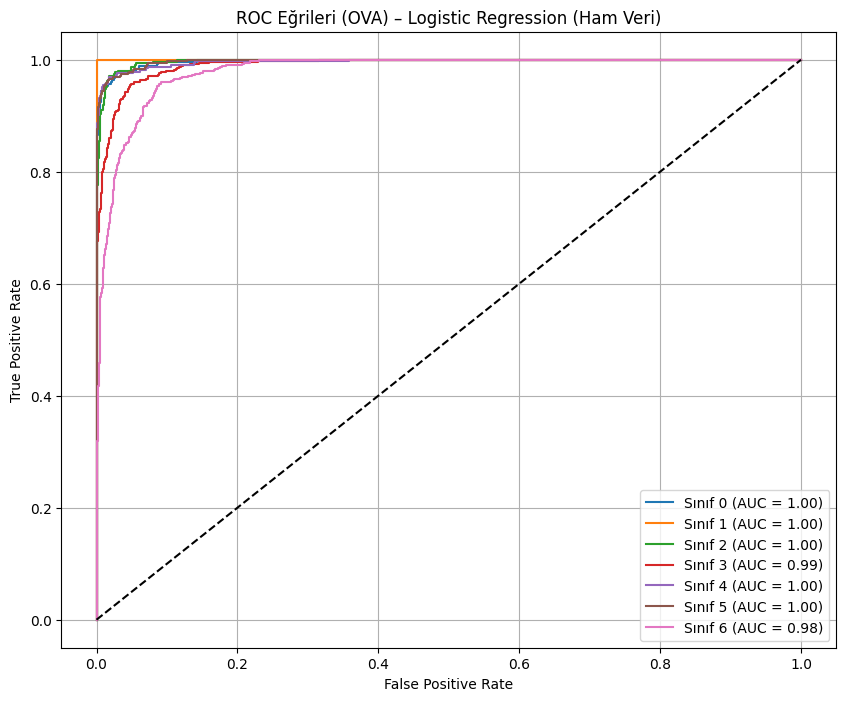


ROC eğrisi çiziliyor: Logistic Regression (PCA Verisi)


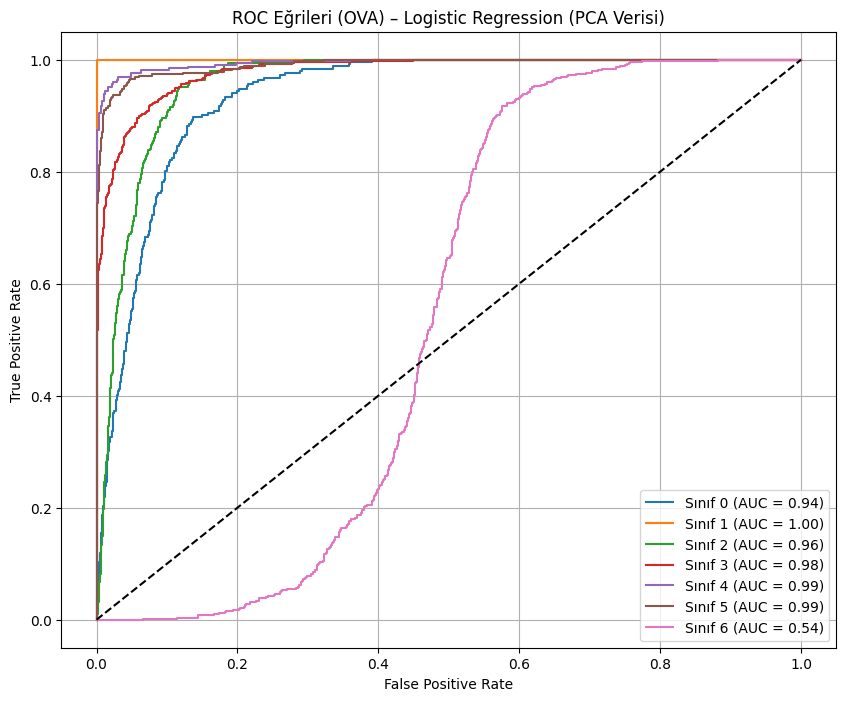


ROC eğrisi çiziliyor: Logistic Regression (LDA Verisi)


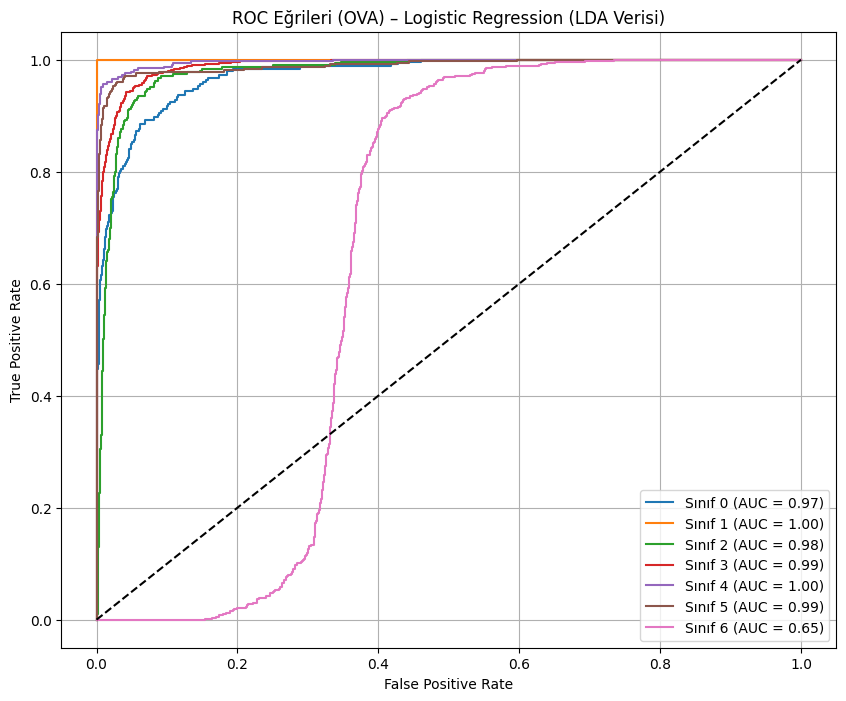


ROC eğrisi çiziliyor: Decision Tree (Ham Veri)


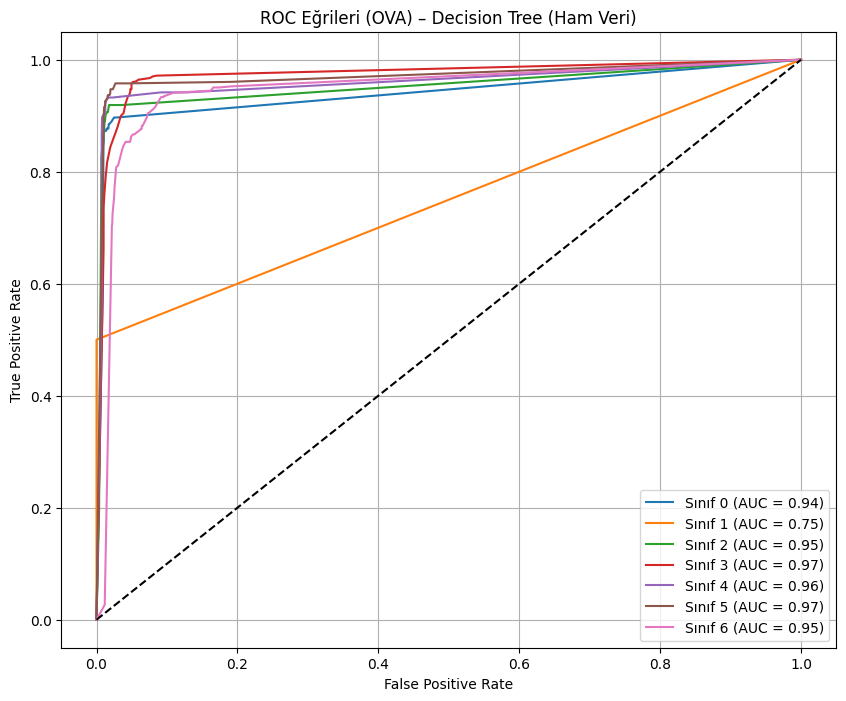


ROC eğrisi çiziliyor: Decision Tree (PCA Verisi)


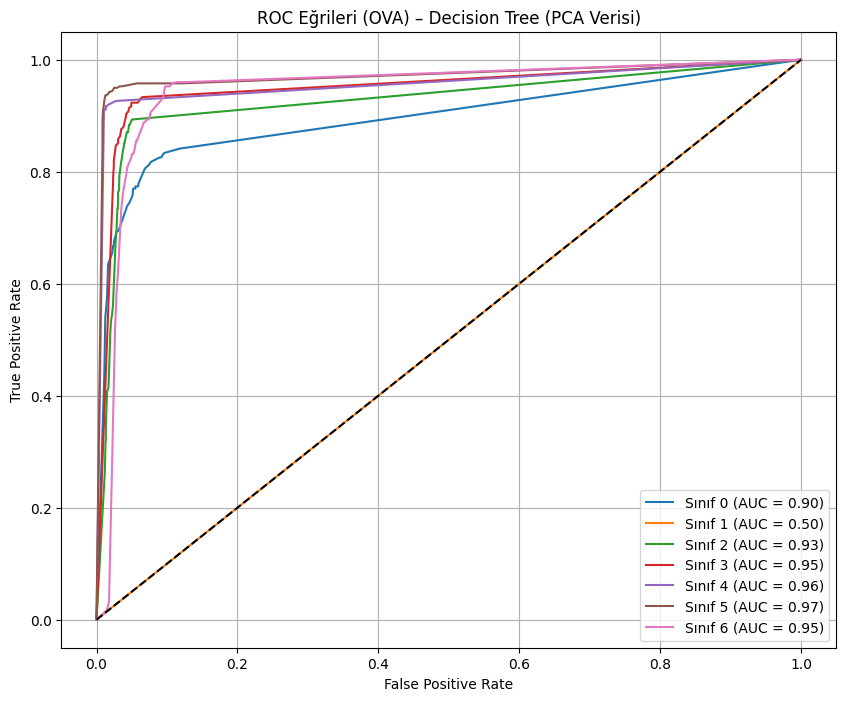


ROC eğrisi çiziliyor: Decision Tree (LDA Verisi)


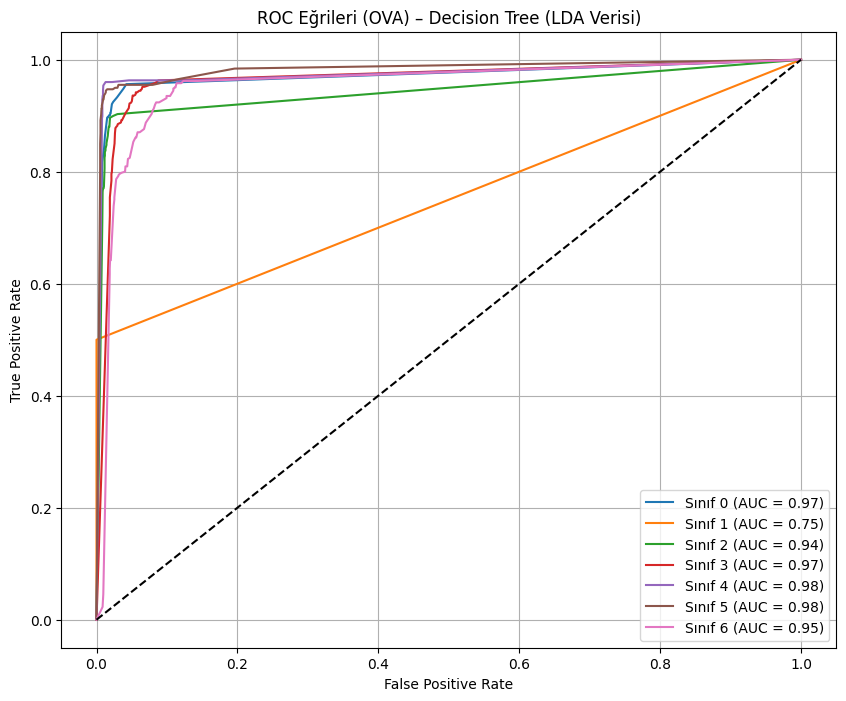


ROC eğrisi çiziliyor: Random Forest (Ham Veri)


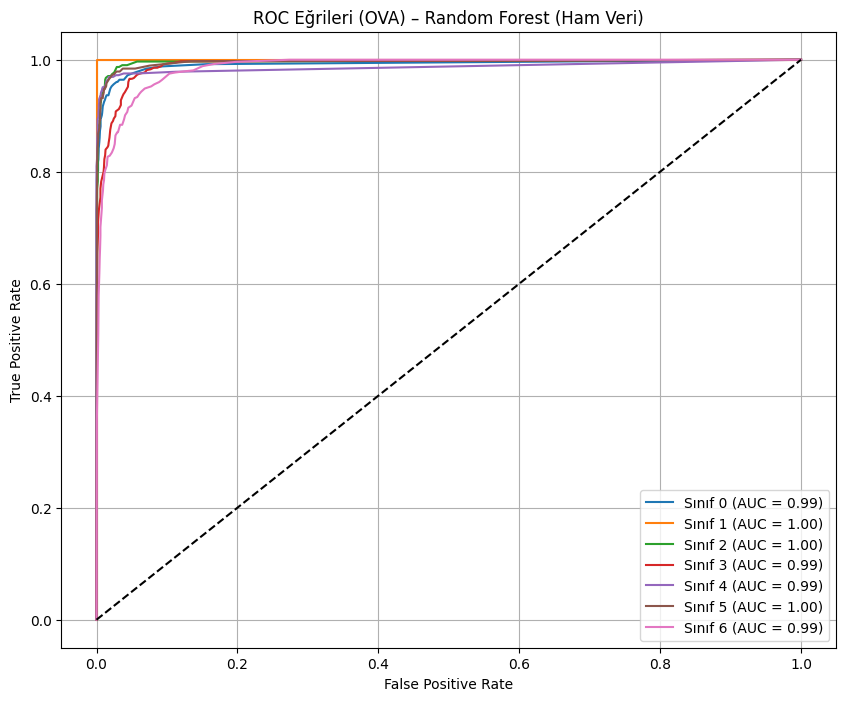


ROC eğrisi çiziliyor: Random Forest (PCA Verisi)


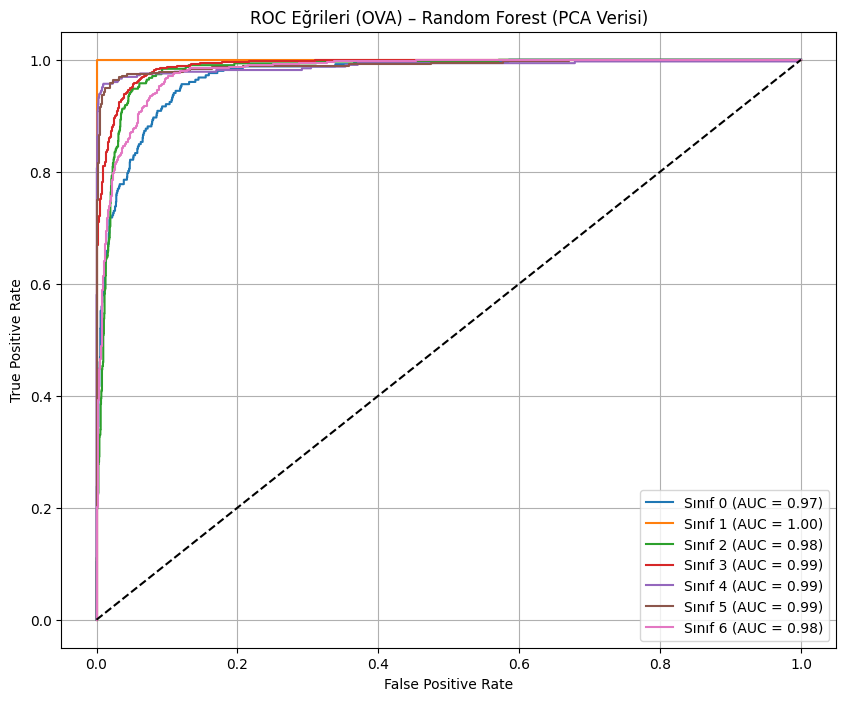


ROC eğrisi çiziliyor: Random Forest (LDA Verisi)


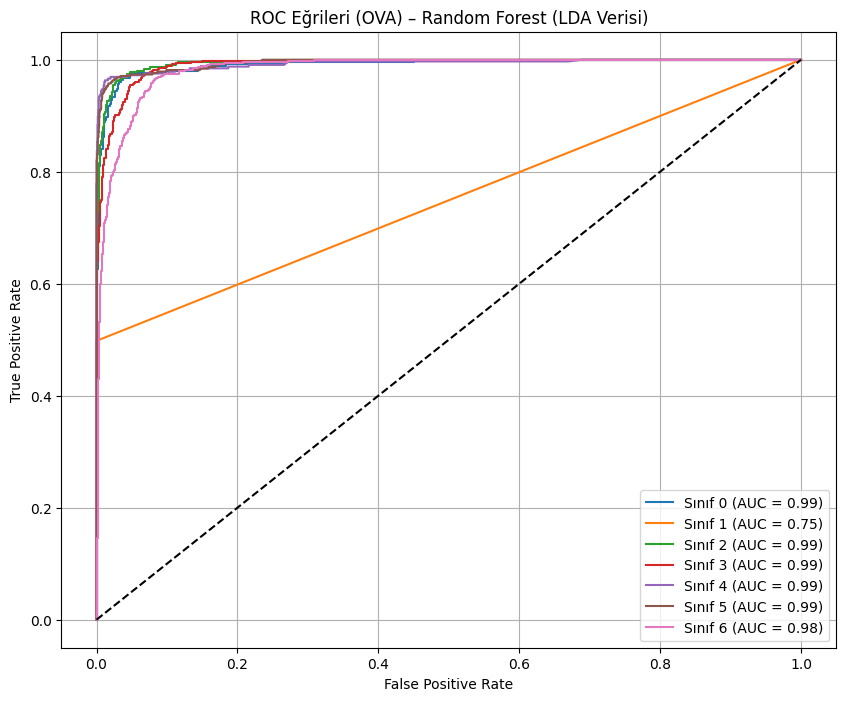


ROC eğrisi çiziliyor: XGBoost (Ham Veri)


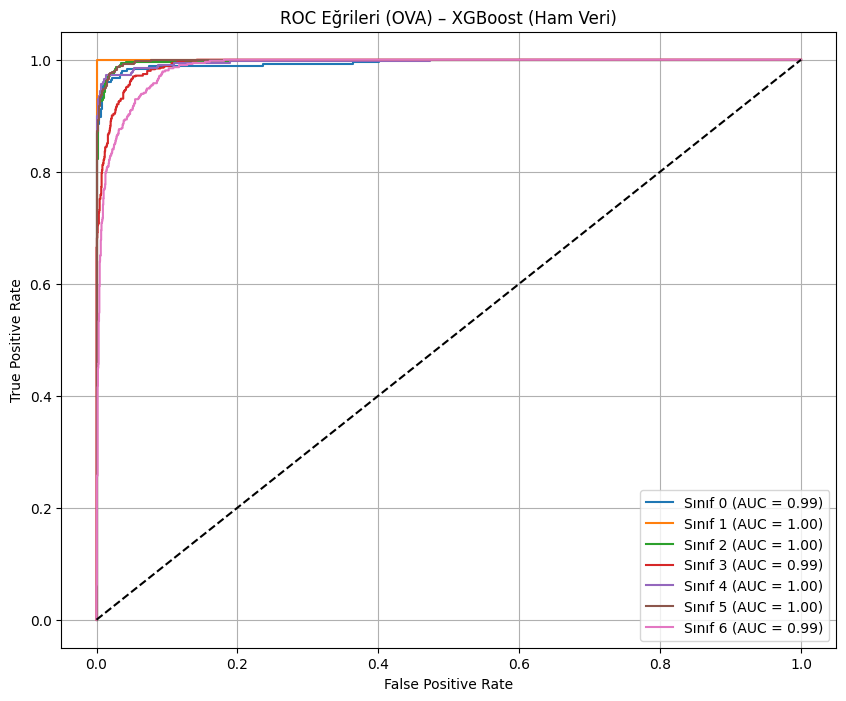


ROC eğrisi çiziliyor: XGBoost (PCA Verisi)


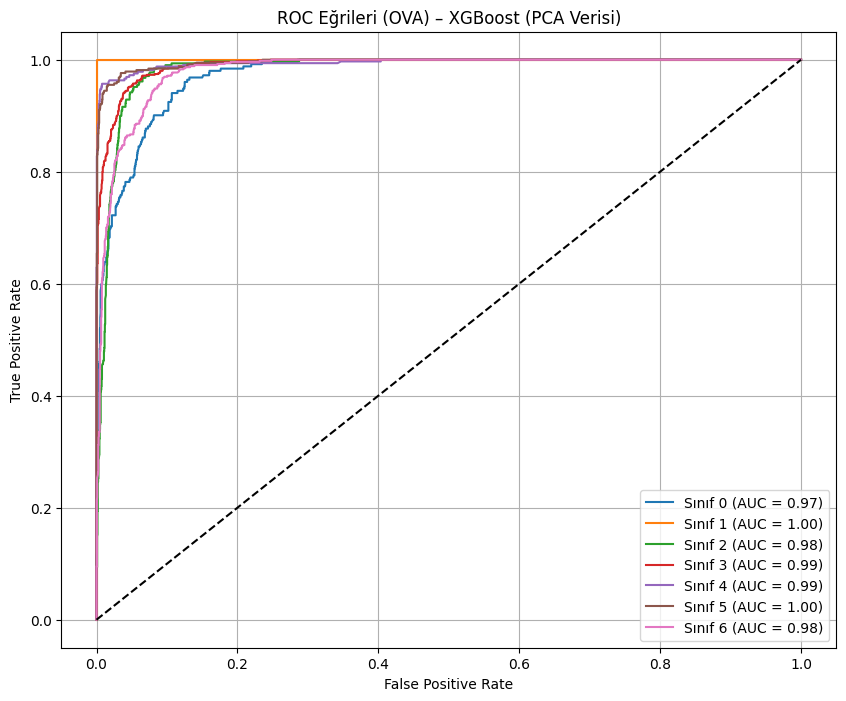


ROC eğrisi çiziliyor: XGBoost (LDA Verisi)


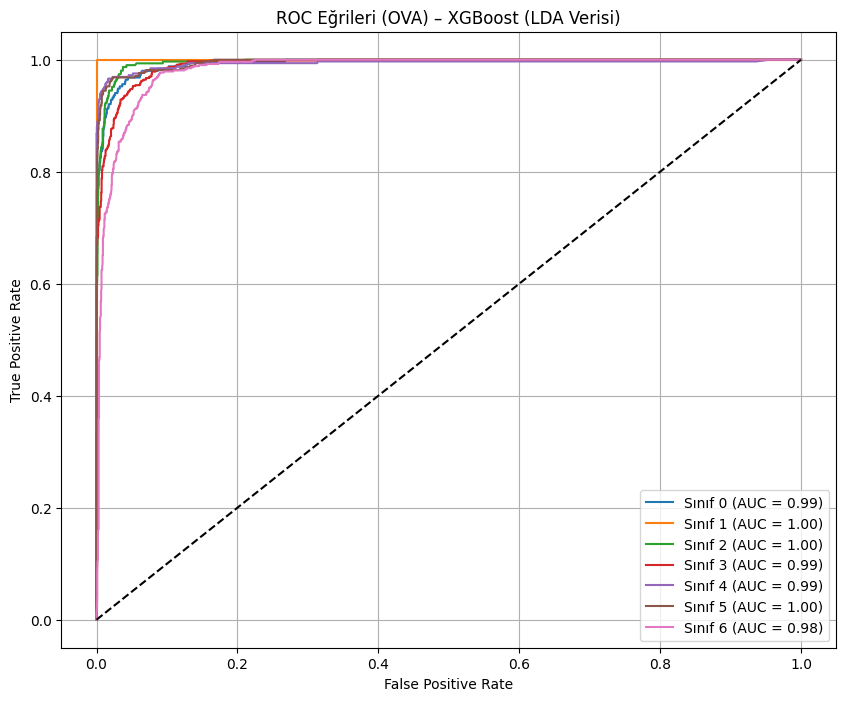


ROC eğrisi çiziliyor: Naive Bayes (Ham Veri)


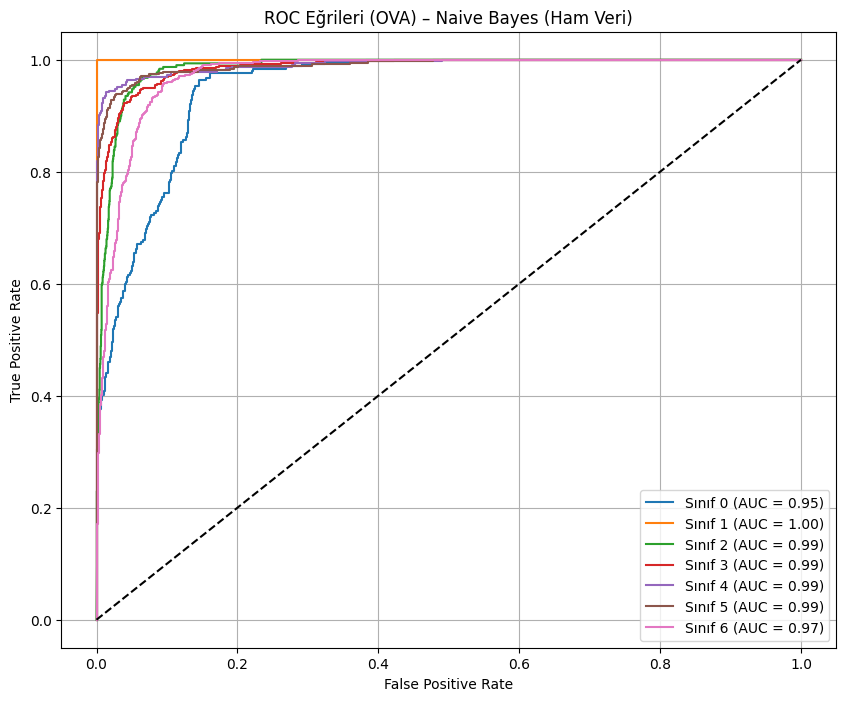


ROC eğrisi çiziliyor: Naive Bayes (PCA Verisi)


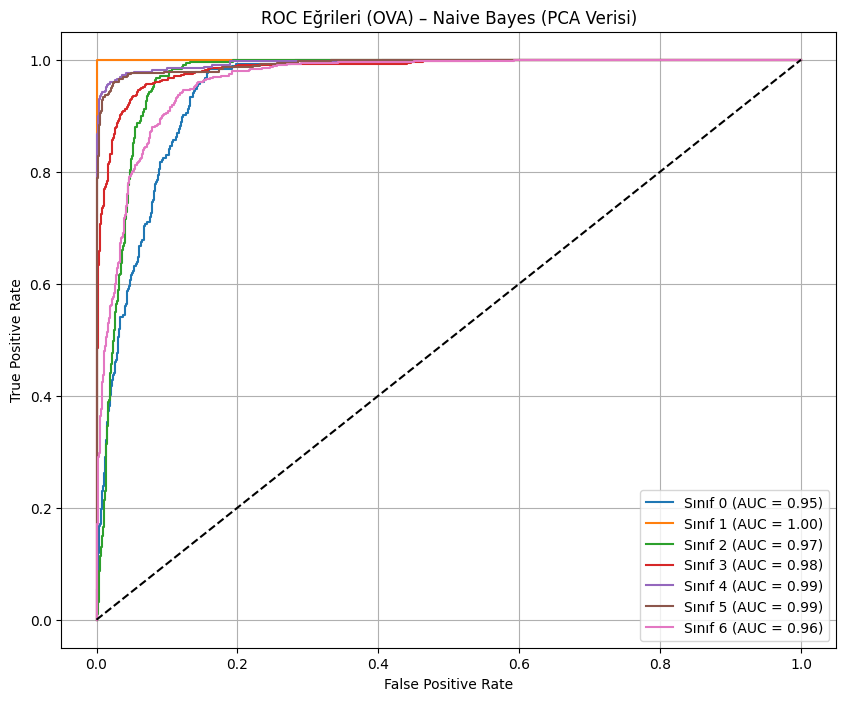


ROC eğrisi çiziliyor: Naive Bayes (LDA Verisi)


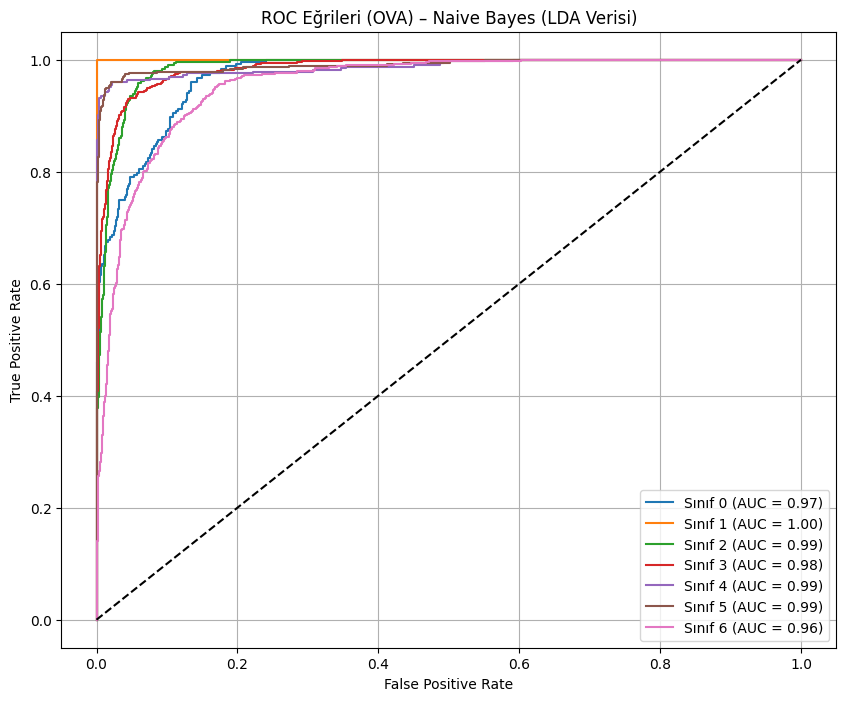

In [70]:
datasets = [
    (X_ham, y_ham, "Ham Veri"),
    (X_pca_data, y_pca_data, "PCA Verisi"),
    (X_lda_data, y_lda_data, "LDA Verisi")
]

for model_name, config in model_and_grids.items():
    for X_data, y_data, data_label in datasets:
        model = config["model"]
        params = config["params"]

        # Fix for XGBoost
        if isinstance(model, XGBClassifier):
            model.set_params(num_class=len(np.unique(y_data)))

    
        full_label = f"{model_name} ({data_label})"
        print(f"\nROC eğrisi çiziliyor: {full_label}")
        plot_roc_curve_ova_best_outer(X_data, y_data, model=model, param_grid=params, label=full_label)
